In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load cleaned data
df = pd.read_csv('../data/processed/superstore_clean.csv', encoding='latin-1')
print("Shape:", df.shape)
df.head()

Shape: (9994, 25)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit_Margin,Order_Year,Order_Month,Order_Quarter
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,16.00,2016,11,4
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,30.00,2016,11,4
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,47.00,2016,6,2
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-40.00,2015,10,4
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11.25,2015,10,4


In [2]:
# Numeric columns summary
print("=== NUMERIC SUMMARY ===")
print(df[['Sales', 'Profit', 'Quantity', 'Discount']].describe())

print("\n=== CATEGORICAL SUMMARY ===")
print("Regions:\n", df['Region'].value_counts())
print("\nCategories:\n", df['Category'].value_counts())
print("\nSub-Categories:\n", df['Sub-Category'].value_counts().head(10))

=== NUMERIC SUMMARY ===
              Sales       Profit     Quantity     Discount
count   9994.000000  9994.000000  9994.000000  9994.000000
mean     229.858001    28.656896     3.789574     0.156203
std      623.245101   234.260108     2.225110     0.206452
min        0.444000 -6599.978000     1.000000     0.000000
25%       17.280000     1.728750     2.000000     0.000000
50%       54.490000     8.666500     3.000000     0.200000
75%      209.940000    29.364000     5.000000     0.200000
max    22638.480000  8399.976000    14.000000     0.800000

=== CATEGORICAL SUMMARY ===
Regions:
 Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

Categories:
 Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

Sub-Categories:
 Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          6

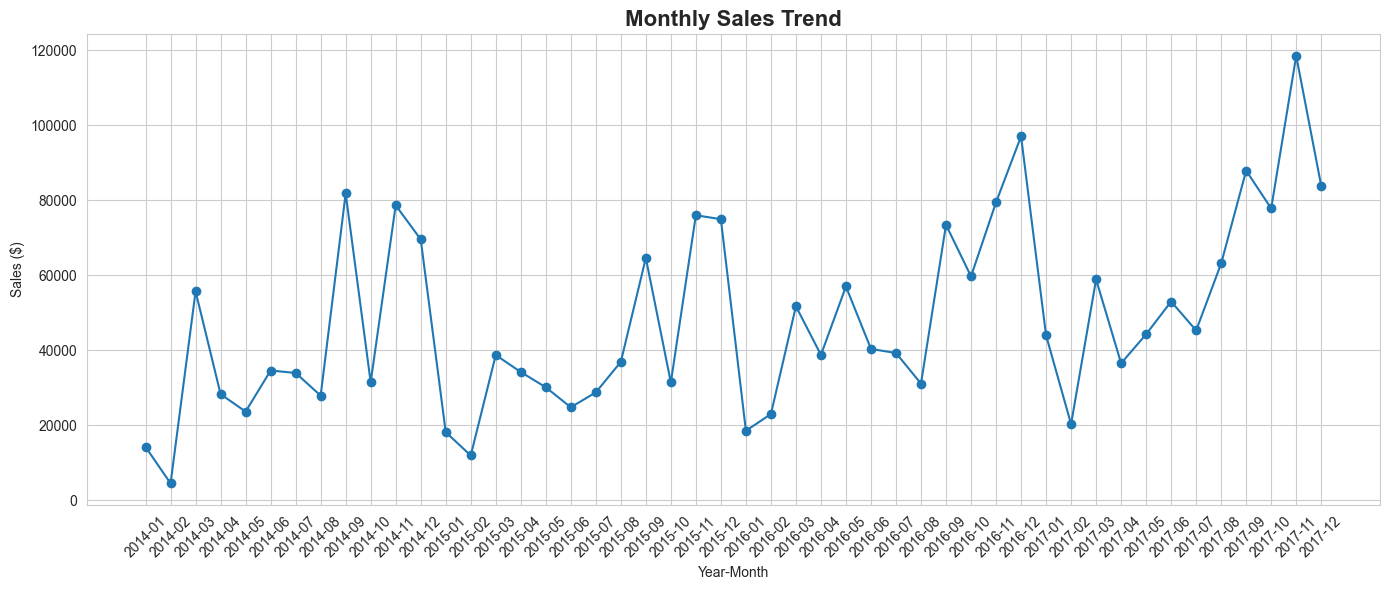

In [3]:
# Monthly sales trend
monthly_sales = df.groupby(['Order_Year', 'Order_Month'])['Sales'].sum().reset_index()
monthly_sales['Year_Month'] = monthly_sales['Order_Year'].astype(str) + '-' + monthly_sales['Order_Month'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Year_Month'], monthly_sales['Sales'], marker='o')
plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Year-Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()

=== REGIONAL PERFORMANCE ===
             Sales     Profit  Profit_Margin
Region                                      
West     725457.82  108418.45          21.95
East     678781.24   91522.78          16.72
Central  501239.89   39706.36         -10.41
South    391721.90   46749.43          16.35


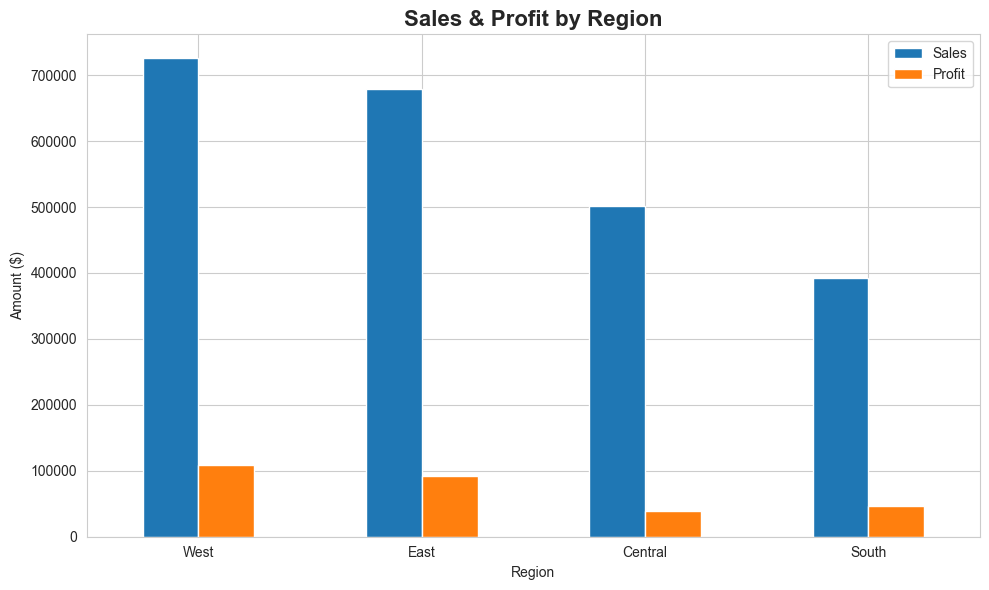

In [4]:
# Regional sales and profit
regional = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Profit_Margin': 'mean'
}).round(2).sort_values('Sales', ascending=False)

print("=== REGIONAL PERFORMANCE ===")
print(regional)

# Bar chart
regional[['Sales', 'Profit']].plot(kind='bar', figsize=(10, 6))
plt.title('Sales & Profit by Region', fontsize=16, fontweight='bold')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig('../images/regional_performance.png', dpi=300, bbox_inches='tight')
plt.show()

=== PARETO ANALYSIS ===
Total Products: 1850
Top 20% Products: 370
Revenue from Top 20%: $1,765,153.53
Total Revenue: $2,297,200.86
Percentage of Total Revenue: 76.8%

 KEY INSIGHT: Top 20% of products generate 77% of total revenue!


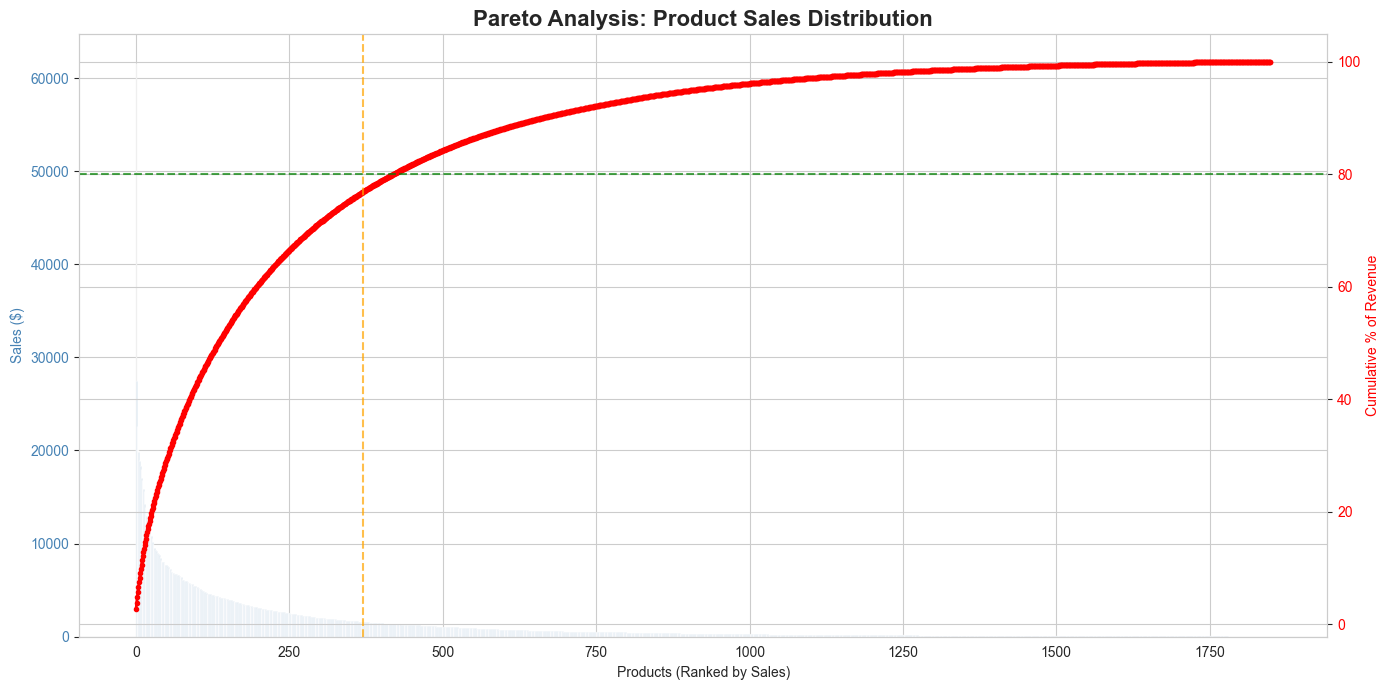

In [6]:
# Pareto Analysis: Which products drive the most revenue?
product_sales = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).reset_index()
product_sales['Cumulative_Sales'] = product_sales['Sales'].cumsum()
product_sales['Cumulative_Percent'] = (product_sales['Cumulative_Sales'] / product_sales['Sales'].sum()) * 100
product_sales['Rank_Percent'] = (np.arange(len(product_sales)) + 1) / len(product_sales) * 100

# Find top 20% products
top_20_percent = product_sales[product_sales['Rank_Percent'] <= 20]
revenue_from_top_20 = top_20_percent['Sales'].sum()
total_revenue = product_sales['Sales'].sum()
percentage = (revenue_from_top_20 / total_revenue) * 100

print(f"=== PARETO ANALYSIS ===")
print(f"Total Products: {len(product_sales)}")
print(f"Top 20% Products: {len(top_20_percent)}")
print(f"Revenue from Top 20%: ${revenue_from_top_20:,.2f}")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Percentage of Total Revenue: {percentage:.1f}%")
print(f"\n KEY INSIGHT: Top 20% of products generate {percentage:.0f}% of total revenue!")

# Plot Pareto chart
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar chart
bars = ax1.bar(range(len(product_sales)), product_sales['Sales'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Products (Ranked by Sales)')
ax1.set_ylabel('Sales ($)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line chart for cumulative %
ax2 = ax1.twinx()
ax2.plot(range(len(product_sales)), product_sales['Cumulative_Percent'], color='red', linewidth=2, marker='o', markersize=3)
ax2.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% Revenue')
ax2.axvline(x=len(top_20_percent), color='orange', linestyle='--', alpha=0.7, label=f'Top 20% Products')
ax2.set_ylabel('Cumulative % of Revenue', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Pareto Analysis: Product Sales Distribution', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.savefig('../images/pareto_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

=== TOP 10 PROFIT MARGIN SUB-CATEGORIES ===
                  Sales    Profit  Profit_Margin
Sub-Category                                    
Labels         12486.31   5546.25          42.97
Paper          78479.21  34053.57          42.56
Envelopes      16476.40   6964.18          42.31
Copiers       149528.03  55617.82          31.72
Fasteners       3024.28    949.52          29.92
Art            27118.79   6527.79          25.16
Accessories   167380.32  41936.64          21.82
Furnishings    91705.16  13059.14          13.71
Phones        330007.05  44515.73          11.92
Supplies       46673.54  -1189.10          11.20

=== BOTTOM 10 PROFIT MARGIN SUB-CATEGORIES ===
                  Sales    Profit  Profit_Margin
Sub-Category                                    
Furnishings    91705.16  13059.14          13.71
Phones        330007.05  44515.73          11.92
Supplies       46673.54  -1189.10          11.20
Storage       223843.61  21278.83           8.91
Chairs        328449.10  2

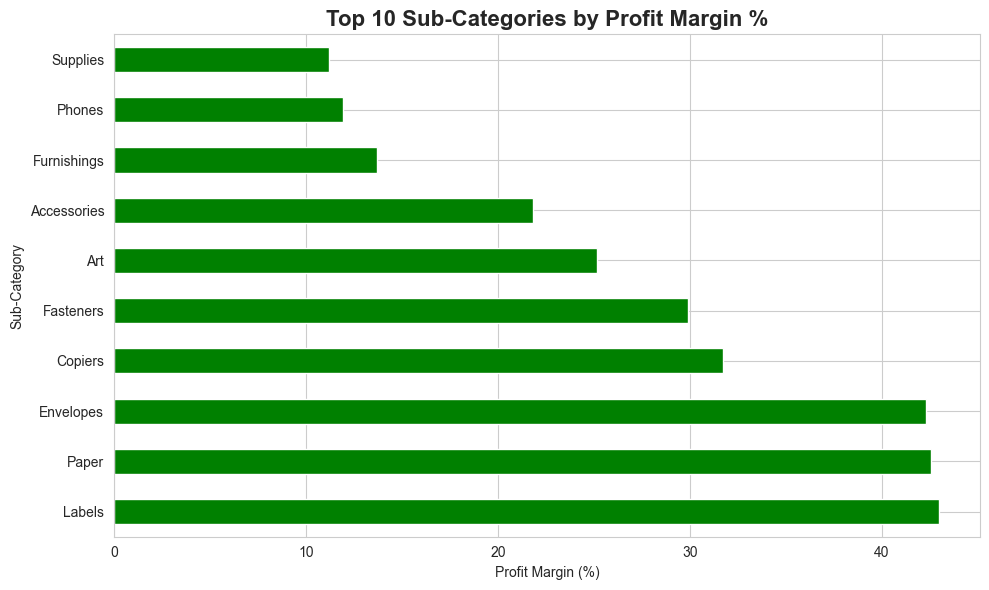

In [7]:
# Sub-categories with highest/lowest profit margins
subcat_profit = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Profit_Margin': 'mean'
}).round(2).sort_values('Profit_Margin', ascending=False)

print("=== TOP 10 PROFIT MARGIN SUB-CATEGORIES ===")
print(subcat_profit.head(10))

print("\n=== BOTTOM 10 PROFIT MARGIN SUB-CATEGORIES ===")
print(subcat_profit.tail(10))

# Plot
subcat_profit['Profit_Margin'].head(10).plot(kind='barh', figsize=(10, 6), color='green')
plt.title('Top 10 Sub-Categories by Profit Margin %', fontsize=16, fontweight='bold')
plt.xlabel('Profit Margin (%)')
plt.tight_layout()
plt.savefig('../images/profit_margin_top10.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# Write SQL queries and execute them using pandas

# SQL 1: Total sales by region
query1 = """
SELECT Region, SUM(Sales) as Total_Sales, SUM(Profit) as Total_Profit
FROM df
GROUP BY Region
ORDER BY Total_Sales DESC
"""
result1 = df.groupby('Region').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index().sort_values('Sales', ascending=False)
print("=== SQL QUERY 1: Sales by Region ===")
print(result1)

# SQL 2: Top 10 products by sales
query2 = """
SELECT `Product Name`, SUM(Sales) as Total_Sales
FROM df
GROUP BY `Product Name`
ORDER BY Total_Sales DESC
LIMIT 10
"""
result2 = df.groupby('Product Name')['Sales'].sum().reset_index().sort_values('Sales', ascending=False).head(10)
print("\n=== SQL QUERY 2: Top 10 Products ===")
print(result2)

# SQL 3: Monthly sales growth
query3 = """
SELECT Order_Year, Order_Month, SUM(Sales) as Monthly_Sales
FROM df
GROUP BY Order_Year, Order_Month
ORDER BY Order_Year, Order_Month
"""
result3 = df.groupby(['Order_Year', 'Order_Month'])['Sales'].sum().reset_index().sort_values(['Order_Year', 'Order_Month'])
print("\n=== SQL QUERY 3: Monthly Sales ===")
print(result3.tail(12))

=== SQL QUERY 1: Sales by Region ===
    Region        Sales       Profit
3     West  725457.8245  108418.4489
1     East  678781.2400   91522.7800
0  Central  501239.8908   39706.3625
2    South  391721.9050   46749.4303

=== SQL QUERY 2: Top 10 Products ===
                                          Product Name      Sales
404              Canon imageCLASS 2200 Advanced Copier  61599.824
650  Fellowes PB500 Electric Punch Plastic Comb Bin...  27453.384
444  Cisco TelePresence System EX90 Videoconferenci...  22638.480
786       HON 5400 Series Task Chairs for Big and Tall  21870.576
686         GBC DocuBind TL300 Electric Binding System  19823.479
688   GBC Ibimaster 500 Manual ProClick Binding System  19024.500
805               Hewlett Packard LaserJet 3310 Copier  18839.686
787  HP Designjet T520 Inkjet Large Format Printer ...  18374.895
683          GBC DocuBind P400 Electric Binding System  17965.068
813        High Speed Automatic Electric Letter Opener  17030.312

=== SQL QUERY

In [9]:
# Save insights to a text file for reference
insights = f"""
SALES PERFORMANCE DASHBOARD - KEY INSIGHTS
==========================================

1. DATASET OVERVIEW:
   - Total Records: {len(df):,}
   - Date Range: {df['Order_Year'].min()} - {df['Order_Year'].max()}
   - Total Revenue: ${df['Sales'].sum():,.2f}
   - Total Profit: ${df['Profit'].sum():,.2f}
   - Overall Profit Margin: {(df['Profit'].sum()/df['Sales'].sum()*100):.2f}%

2. PARETO PRINCIPLE (80/20 RULE):
   - Top 20% products ({len(top_20_percent)} products) generate {percentage:.1f}% of total revenue
   - This validates the business strategy to focus on high-performing products

3. REGIONAL PERFORMANCE:
   - Best Region: {regional.index[0]} (${regional.iloc[0]['Sales']:,.2f} sales)
   - Worst Region: {regional.index[-1]} (${regional.iloc[-1]['Sales']:,.2f} sales)

4. PROFITABILITY INSIGHTS:
   - Highest Margin Sub-Category: {subcat_profit.index[0]} ({subcat_profit.iloc[0]['Profit_Margin']:.2f}%)
   - Lowest Margin Sub-Category: {subcat_profit.index[-1]} ({subcat_profit.iloc[-1]['Profit_Margin']:.2f}%)

5. BUSINESS RECOMMENDATIONS:
   - Focus marketing budget on top 20% products
   - Investigate low-margin sub-categories for cost optimization
   - Expand successful strategies from {regional.index[0]} region to {regional.index[-1]}
"""

with open('../sql/insights_summary.txt', 'w') as f:
    f.write(insights)

print("✅ Insights saved to sql/insights_summary.txt")
print(insights)

✅ Insights saved to sql/insights_summary.txt

SALES PERFORMANCE DASHBOARD - KEY INSIGHTS

1. DATASET OVERVIEW:
   - Total Records: 9,994
   - Date Range: 2014 - 2017
   - Total Revenue: $2,297,200.86
   - Total Profit: $286,397.02
   - Overall Profit Margin: 12.47%

2. PARETO PRINCIPLE (80/20 RULE):
   - Top 20% products (370 products) generate 76.8% of total revenue
   - This validates the business strategy to focus on high-performing products

3. REGIONAL PERFORMANCE:
   - Best Region: West ($725,457.82 sales)
   - Worst Region: South ($391,721.90 sales)

4. PROFITABILITY INSIGHTS:
   - Highest Margin Sub-Category: Labels (42.97%)
   - Lowest Margin Sub-Category: Binders (-19.96%)

5. BUSINESS RECOMMENDATIONS:
   - Focus marketing budget on top 20% products
   - Investigate low-margin sub-categories for cost optimization
   - Expand successful strategies from West region to South

